## Catch22 Clustering

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import matplotlib.pyplot as plt

In [2]:
import pycatch22

In [3]:
# Load preprocessing outputs

candidate_paths = [
    Path("../dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("CMI_timeseries_preprocessed_outputs.pkl"),
]

preprocessed_path = None

for path in candidate_paths:
    if path.exists():
        preprocessed_path = path
        break

if preprocessed_path is None:
    raise FileNotFoundError(
        "CMI_timeseries_preprocessed_outputs.pkl not found. "
        "Check the path from the current notebook."
    )

with open(preprocessed_path, "rb") as f:
    preprocessing_output = pickle.load(f)

print("Loaded:", preprocessed_path)
print("\nAvailable keys:")
for key in preprocessing_output.keys():
    print("-", key)

Loaded: ../dataset/CMI_timeseries_preprocessed_outputs.pkl

Available keys:
- CMI_timeseries_preprocessed
- CMI_timeseries_global_scaled
- CMI_timeseries_subject_scaled
- signal_cols
- id_col
- target_col
- target_df
- filtered_target_df
- non_wear_df
- hampel_summary_df


In [4]:
# Select the window-level / subject-wise standardized time-series dataset
# IMPORTANT: this is NOT the globally standardized dataset.

selected_source_name = "CMI_timeseries_subject_scaled"

if selected_source_name not in preprocessing_output:
    raise KeyError(
        f"{selected_source_name} not found in preprocessing_output. "
        f"Available keys are: {list(preprocessing_output.keys())}"
    )

ts_source = preprocessing_output[selected_source_name]

print("Selected time-series source:", selected_source_name)
print("Type:", type(ts_source))
print("Length:", len(ts_source))
print("Shape:", getattr(ts_source, "shape", None))

Selected time-series source: CMI_timeseries_subject_scaled
Type: <class 'list'>
Length: 4310
Shape: None


In [5]:
# Load metadata aligned with the filtered/preprocessed time-series windows

metadata_candidates = [
    "filtered_target_df",
    "metadata_df",
    "CMI_timeseries_metadata_filtered",
]

metadata_df = None
used_metadata_key = None

for key in metadata_candidates:
    if key in preprocessing_output:
        metadata_df = preprocessing_output[key].copy()
        used_metadata_key = key
        break

if metadata_df is None:
    raise KeyError(
        "No aligned metadata dataframe found in preprocessing_output. "
        f"Available keys are: {list(preprocessing_output.keys())}"
    )

print("Using metadata key:", used_metadata_key)
print("metadata_df shape:", metadata_df.shape)
print("metadata_df columns:", metadata_df.columns.tolist())

if len(metadata_df) != len(ts_source):
    raise ValueError(
        f"Length mismatch: ts_source has {len(ts_source)} windows, "
        f"metadata_df has {len(metadata_df)} rows."
    )

Using metadata key: filtered_target_df
metadata_df shape: (4310, 3)
metadata_df columns: ['filtered_series_index', 'subject_id', 'target_value']


In [6]:
# Main sensor signals used for catch22 extraction

if "signal_cols" in preprocessing_output:
    signal_cols = preprocessing_output["signal_cols"]
else:
    signal_cols = ["X", "Y", "Z", "enmo", "anglez"]

print("Signal columns:", signal_cols)

Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']


In [7]:
# Inspect source format

if isinstance(ts_source, list):
    source_type = "list_of_dataframes"
    print("Source type: list of dataframes")
    print("First element type:", type(ts_source[0]))
    print("First element shape:", ts_source[0].shape)
    print("First element columns:", ts_source[0].columns.tolist())

else:
    source_type = "array"
    X_ts = np.asarray(ts_source)

    if X_ts.ndim != 3:
        raise ValueError(f"Expected a 3D array, got shape {X_ts.shape}")

    # Expected orientation: (n_windows, n_timesteps, n_channels)
    # If orientation is (n_windows, n_channels, n_timesteps), transpose it.
    if X_ts.shape[1] == len(signal_cols) and X_ts.shape[2] != len(signal_cols):
        X_ts = np.transpose(X_ts, (0, 2, 1))

    print("Source type: array")
    print("Array shape after orientation check:", X_ts.shape)

Source type: list of dataframes
First element type: <class 'pandas.core.frame.DataFrame'>
First element shape: (200, 13)
First element columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


In [8]:
# Robust identification of subject-id and target columns

candidate_id_cols = ["subject_id", "id", "participant_id", "PCIAT_id"]
candidate_target_cols = ["target", "sii_binary", "sii", "label", "class"]

id_col = None
for col in candidate_id_cols:
    if col in metadata_df.columns:
        id_col = col
        break

target_col = None
for col in candidate_target_cols:
    if col in metadata_df.columns:
        target_col = col
        break

if id_col is None:
    print("No subject-id column found. The dataframe index will be used as subject_id.")
else:
    print("Using subject-id column:", id_col)

if target_col is None:
    print("No target column found. Clustering will be unsupervised without target labels.")
else:
    print("Using target column:", target_col)

Using subject-id column: subject_id
No target column found. Clustering will be unsupervised without target labels.


In [9]:
# Extract catch22 features from CMI_timeseries_subject_scaled

catch22_rows = []

for i in tqdm(range(len(ts_source)), desc="Extracting catch22 features"):

    if id_col is None:
        subject_value = metadata_df.index[i]
    else:
        subject_value = metadata_df.iloc[i][id_col]

    if target_col is None:
        target_value = np.nan
    else:
        target_value = metadata_df.iloc[i][target_col]

    row = {
        "window_index": i,
        "subject_id": subject_value,
        "target": target_value,
    }

    if source_type == "list_of_dataframes":
        ts_df = ts_source[i]

        for signal in signal_cols:
            x = ts_df[signal].to_numpy(dtype=float)

            finite_x = x[np.isfinite(x)]
            fill_value = np.median(finite_x) if len(finite_x) > 0 else 0.0

            x = np.nan_to_num(
                x,
                nan=fill_value,
                posinf=np.max(finite_x) if len(finite_x) > 0 else fill_value,
                neginf=np.min(finite_x) if len(finite_x) > 0 else fill_value,
            )

            features = pycatch22.catch22_all(x, catch24=False)

            for feature_name, feature_value in zip(features["names"], features["values"]):
                row[f"{signal}_{feature_name}"] = feature_value

    else:
        for channel_idx, signal in enumerate(signal_cols):
            x = X_ts[i, :, channel_idx].astype(float)

            finite_x = x[np.isfinite(x)]
            fill_value = np.median(finite_x) if len(finite_x) > 0 else 0.0

            x = np.nan_to_num(
                x,
                nan=fill_value,
                posinf=np.max(finite_x) if len(finite_x) > 0 else fill_value,
                neginf=np.min(finite_x) if len(finite_x) > 0 else fill_value,
            )

            features = pycatch22.catch22_all(x, catch24=False)

            for feature_name, feature_value in zip(features["names"], features["values"]):
                row[f"{signal}_{feature_name}"] = feature_value

    catch22_rows.append(row)

catch22_df = pd.DataFrame(catch22_rows)

print("catch22 dataframe shape:", catch22_df.shape)
display(catch22_df.head())

Extracting catch22 features:   0%|          | 0/4310 [00:00<?, ?it/s]

catch22 dataframe shape: (4310, 135)


,window_index,subject_id,target,X_DN_HistogramMode_5,X_DN_HistogramMode_10,X_CO_f1ecac,X_CO_FirstMin_ac,X_CO_HistogramAMI_even_2_5,X_CO_trev_1_num,X_MD_hrv_classic_pnn40,...,light_FC_LocalSimple_mean1_tauresrat,light_DN_OutlierInclude_p_001_mdrmd,light_DN_OutlierInclude_n_001_mdrmd,light_SP_Summaries_welch_rect_area_5_1,light_SB_BinaryStats_diff_longstretch0,light_SB_MotifThree_quantile_hh,light_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,light_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,light_SP_Summaries_welch_rect_centroid,light_FC_LocalSimple_mean3_stderr
0,0,2265,NaN,-0.358445,-0.634726,11.808581,2,0.314121,0.186493,0.924623,...,0.285714,-0.290,0.2400,0.696832,18.0,1.833745,0.166667,0.857143,0.368155,0.858133
1,1,3042,NaN,-0.641711,-0.415348,2.991347,4,0.163565,-0.233427,0.904523,...,0.166667,0.185,-0.0600,0.744738,8.0,1.724855,0.142857,0.714286,0.368155,0.836142
2,2,1647,NaN,-0.288559,-0.501250,1.556821,7,0.103191,-0.020896,0.934673,...,0.285714,0.240,-0.0375,0.793631,42.0,1.907350,0.190476,0.857143,0.294524,0.728226
3,3,736,NaN,0.756031,0.931312,17.138908,5,0.353147,0.023399,0.899497,...,0.142857,0.440,-0.1050,0.505676,6.0,2.006944,0.619048,0.809524,0.539961,1.004177
4,4,1044,NaN,0.829709,0.599949,3.971916,9,0.267672,0.021962,0.934673,...,0.100000,0.180,0.3300,0.554557,7.0,1.854455,0.142857,0.857143,0.466330,0.933385


In [10]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

catch22_output_path = output_dir / "catch22_window_level_scaled_features.csv"

catch22_df.to_csv(catch22_output_path, index=False)

print("Saved catch22 features to:", catch22_output_path)

Saved catch22 features to: outputs/catch22_window_level_scaled_features.csv


In [11]:
# Prepare catch22 feature matrix

metadata_cols = ["window_index", "subject_id", "target"]

catch22_feature_cols = [
    col for col in catch22_df.columns
    if col not in metadata_cols
]

X_catch22 = catch22_df[catch22_feature_cols].copy()

# Replace inf with nan, then impute with median
X_catch22 = X_catch22.replace([np.inf, -np.inf], np.nan)

nan_counts = X_catch22.isna().sum().sum()
print("Total missing values before imputation:", nan_counts)

X_catch22 = X_catch22.fillna(X_catch22.median())

scaler = StandardScaler()
X_catch22_scaled = scaler.fit_transform(X_catch22)

print("X_catch22_scaled shape:", X_catch22_scaled.shape)

Total missing values before imputation: 152
X_catch22_scaled shape: (4310, 132)


Explained variance ratio: [0.17132471 0.06098756]
Total explained variance: 0.23231227287175288


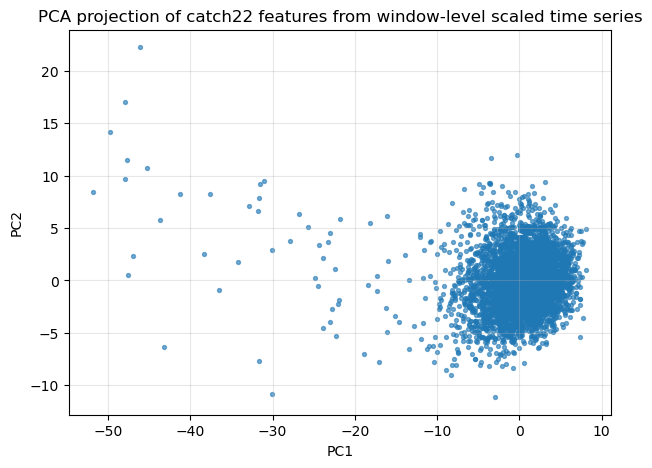

In [12]:
# PCA projection for visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_catch22_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of catch22 features from window-level scaled time series")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# KMeans clustering on catch22 features

k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_catch22_scaled)

    sil = silhouette_score(X_catch22_scaled, labels)
    ch = calinski_harabasz_score(X_catch22_scaled, labels)
    db = davies_bouldin_score(X_catch22_scaled, labels)

    kmeans_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "inertia": model.inertia_
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia
0,2,0.660707,431.016755,1.117457,517176.344130
1,3,0.081565,384.860216,2.715237,482661.685466
2,4,0.050075,305.562027,3.119200,469063.137510
3,5,0.052208,261.548742,3.029135,457692.275043
4,6,0.031517,231.077269,3.119342,448517.750066
5,7,0.033690,210.179854,3.032619,439976.266568
6,8,0.034798,192.487965,2.975002,433229.672641
7,9,0.026506,175.669367,3.168218,428806.996504
8,10,0.021852,161.672477,3.258607,425079.717004


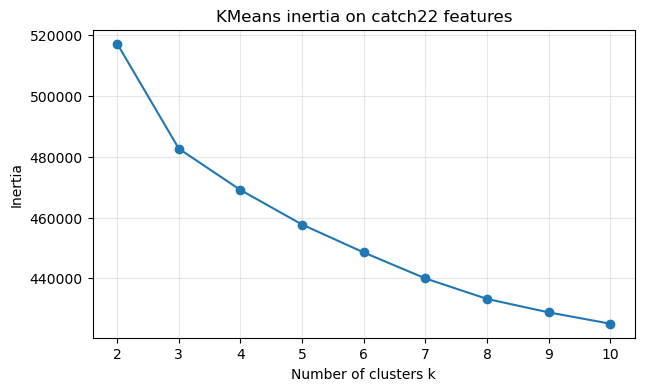

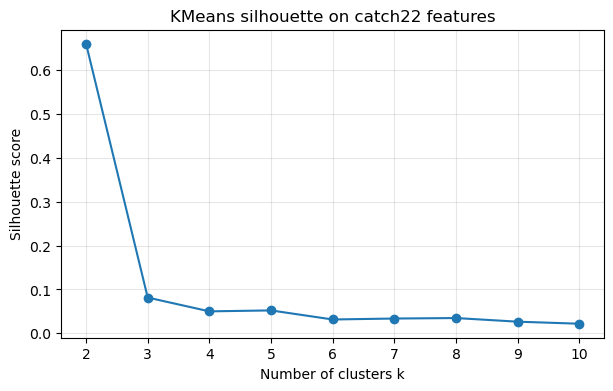

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans inertia on catch22 features")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["silhouette"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("KMeans silhouette on catch22 features")
plt.grid(alpha=0.3)
plt.show()

In [15]:
best_k = int(kmeans_results_df.loc[kmeans_results_df["silhouette"].idxmax(), "k"])

print("Best k according to silhouette:", best_k)

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

catch22_df["kmeans_cluster"] = kmeans_final.fit_predict(X_catch22_scaled)

print(catch22_df["kmeans_cluster"].value_counts().sort_index())

Best k according to silhouette: 2
kmeans_cluster
0    4265
1      45
Name: count, dtype: int64


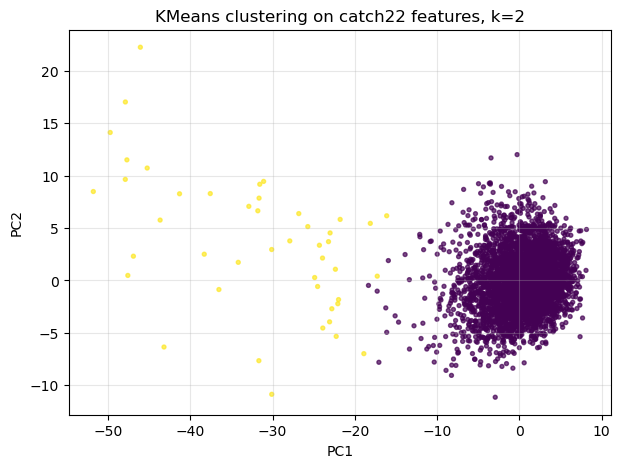

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=catch22_df["kmeans_cluster"],
    s=8,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans clustering on catch22 features, k={best_k}")
plt.grid(alpha=0.3)
plt.show()

In [17]:
# DBSCAN grid search on catch22 features

dbscan_results = []

eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
min_samples_values = [5, 10, 20, 30, 50]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_catch22_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)

        if n_clusters >= 2:
            mask = labels != -1

            if mask.sum() > 1 and len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_catch22_scaled[mask], labels[mask])
            else:
                sil = np.nan
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette_no_noise": sil
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df.sort_values(
    by=["silhouette_no_noise", "n_clusters"],
    ascending=[False, False]
))

,eps,min_samples,n_clusters,noise_ratio,silhouette_no_noise
0,1.5,5,0,1.0,NaN
1,1.5,10,0,1.0,NaN
2,1.5,20,0,1.0,NaN
3,1.5,30,0,1.0,NaN
4,1.5,50,0,1.0,NaN
5,2.0,5,0,1.0,NaN
6,2.0,10,0,1.0,NaN
7,2.0,20,0,1.0,NaN
8,2.0,30,0,1.0,NaN
9,2.0,50,0,1.0,NaN


In [18]:
valid_dbscan = dbscan_results_df.dropna(subset=["silhouette_no_noise"]).copy()

if len(valid_dbscan) == 0:
    print("No valid DBSCAN configuration found.")
else:
    best_dbscan_row = valid_dbscan.sort_values(
        by=["silhouette_no_noise", "n_clusters"],
        ascending=[False, False]
    ).iloc[0]

    best_eps = best_dbscan_row["eps"]
    best_min_samples = int(best_dbscan_row["min_samples"])

    print("Best DBSCAN configuration:")
    print(best_dbscan_row)

    dbscan_final = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )

    catch22_df["dbscan_cluster"] = dbscan_final.fit_predict(X_catch22_scaled)

    print(catch22_df["dbscan_cluster"].value_counts().sort_index())

No valid DBSCAN configuration found.


In [19]:
# OPTICS clustering on catch22 features

optics_model = OPTICS(
    min_samples=20,
    xi=0.05,
    min_cluster_size=0.03
)

catch22_df["optics_cluster"] = optics_model.fit_predict(X_catch22_scaled)

print(catch22_df["optics_cluster"].value_counts().sort_index())

optics_cluster
-1      47
 0    4263
Name: count, dtype: int64


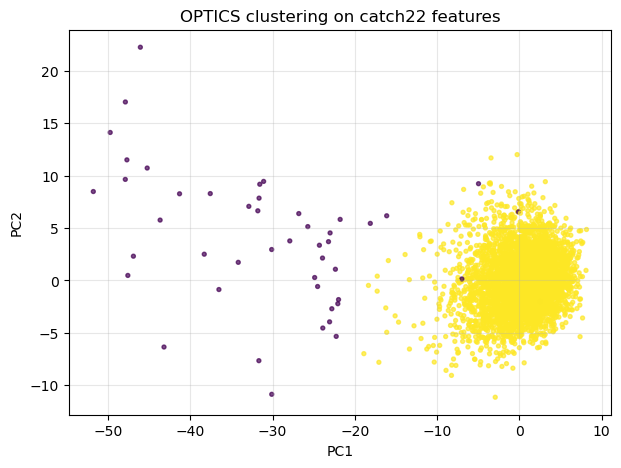

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=catch22_df["optics_cluster"],
    s=8,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("OPTICS clustering on catch22 features")
plt.grid(alpha=0.3)
plt.show()

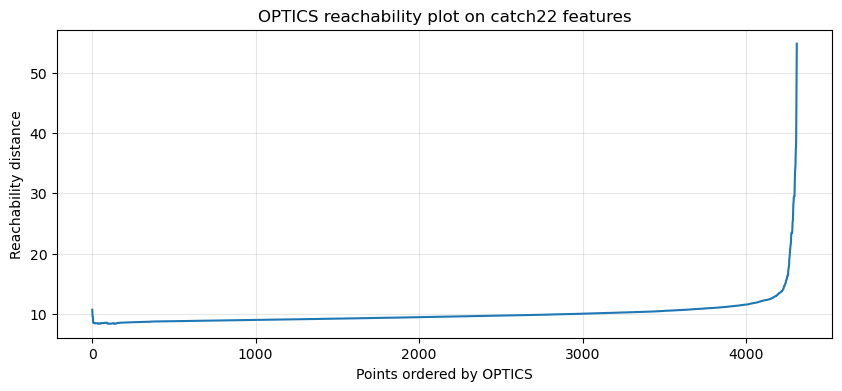

In [21]:
space = np.arange(len(X_catch22_scaled))
reachability = optics_model.reachability_[optics_model.ordering_]
labels_ordered = optics_model.labels_[optics_model.ordering_]

plt.figure(figsize=(10, 4))
plt.plot(space, reachability)
plt.xlabel("Points ordered by OPTICS")
plt.ylabel("Reachability distance")
plt.title("OPTICS reachability plot on catch22 features")
plt.grid(alpha=0.3)
plt.show()

Explained variance ratio:
PC1: 0.1713
PC2: 0.061
Total: 0.2323


,PC1,PC2,target
0,-2.146907,-1.748652,NaN
1,3.840306,1.481326,NaN
2,0.050270,-2.521126,NaN
3,-0.119136,1.987194,NaN
4,-2.487922,1.861585,NaN


/var/folders/pw/y3ztzc9n5ns3pn2xk2j59d2w0000gp/T/ipykernel_13678/1646297572.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Target")


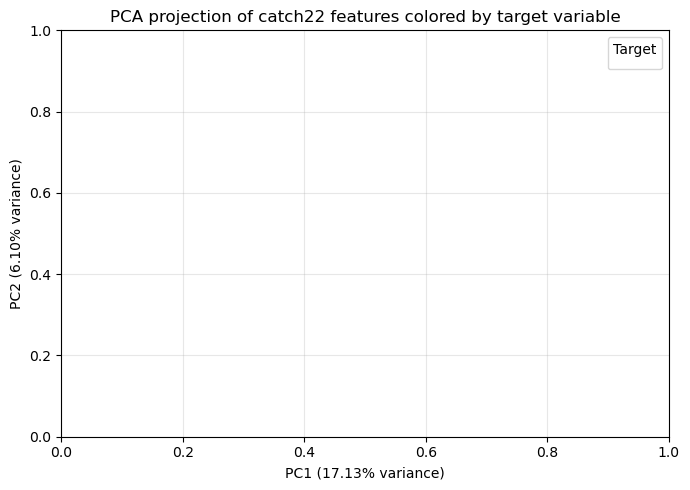

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PCA on standardized catch22 feature matrix
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_catch22_scaled)

# Store PCA coordinates
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "target": catch22_df["target"].values
})

print("Explained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total:", round(pca.explained_variance_ratio_.sum(), 4))

display(pca_df.head())

# Plot PCA colored by target variable
plt.figure(figsize=(7, 5))

targets = sorted(pca_df["target"].dropna().unique())

for target_value in targets:
    mask = pca_df["target"] == target_value
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        s=10,
        alpha=0.65,
        label=f"Target = {target_value}"
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.title("PCA projection of catch22 features colored by target variable")
plt.legend(title="Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Fix target column if it was not correctly stored in catch22_df

if catch22_df["target"].isna().all():
    if "target_value" in metadata_df.columns:
        catch22_df["target"] = metadata_df["target_value"].values
        print("Target column fixed using metadata_df['target_value'].")
    elif "target" in metadata_df.columns:
        catch22_df["target"] = metadata_df["target"].values
        print("Target column fixed using metadata_df['target'].")
    else:
        raise KeyError(
            f"No valid target column found in metadata_df. "
            f"Available columns are: {metadata_df.columns.tolist()}"
        )

print(catch22_df["target"].value_counts(dropna=False))

Target column fixed using metadata_df['target_value'].
target
0    2888
1    1422
Name: count, dtype: int64


catch22_df columns:
['window_index', 'subject_id', 'target', 'X_DN_HistogramMode_5', 'X_DN_HistogramMode_10', 'X_CO_f1ecac', 'X_CO_FirstMin_ac', 'X_CO_HistogramAMI_even_2_5', 'X_CO_trev_1_num', 'X_MD_hrv_classic_pnn40', 'X_SB_BinaryStats_mean_longstretch1', 'X_SB_TransitionMatrix_3ac_sumdiagcov', 'X_PD_PeriodicityWang_th0_01', 'X_CO_Embed2_Dist_tau_d_expfit_meandiff', 'X_IN_AutoMutualInfoStats_40_gaussian_fmmi', 'X_FC_LocalSimple_mean1_tauresrat', 'X_DN_OutlierInclude_p_001_mdrmd', 'X_DN_OutlierInclude_n_001_mdrmd', 'X_SP_Summaries_welch_rect_area_5_1', 'X_SB_BinaryStats_diff_longstretch0', 'X_SB_MotifThree_quantile_hh', 'X_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1', 'X_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1', 'X_SP_Summaries_welch_rect_centroid', 'X_FC_LocalSimple_mean3_stderr', 'Y_DN_HistogramMode_5', 'Y_DN_HistogramMode_10', 'Y_CO_f1ecac', 'Y_CO_FirstMin_ac', 'Y_CO_HistogramAMI_even_2_5', 'Y_CO_trev_1_num', 'Y_MD_hrv_classic_pnn40', 'Y_SB_BinaryStats_mean_longstretch1', 'Y_SB_Tran

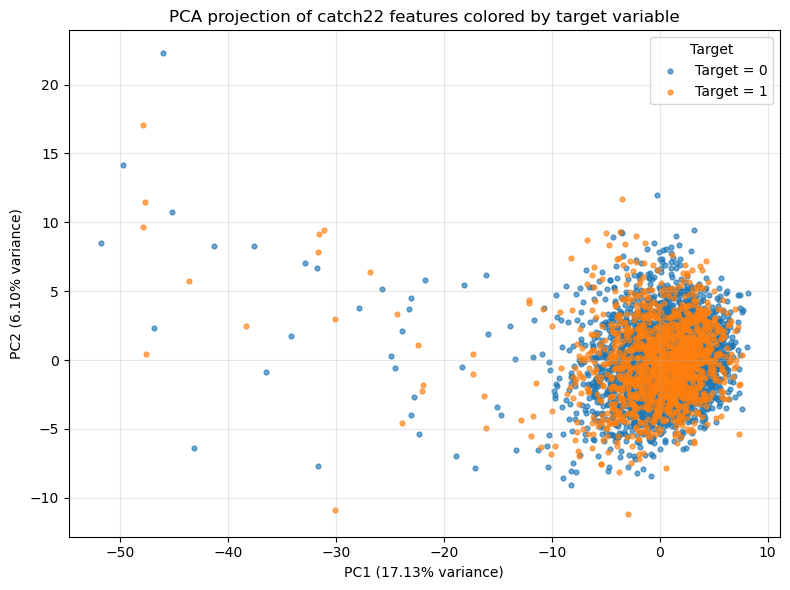

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PCA on standardized catch22 feature matrix
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_catch22_scaled)

# Check target column
print("catch22_df columns:")
print(catch22_df.columns.tolist())

if "target" not in catch22_df.columns:
    raise KeyError("The column 'target' is not present in catch22_df.")

print("\nTarget value counts:")
print(catch22_df["target"].value_counts(dropna=False))

# Build PCA dataframe
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "target": catch22_df["target"].values
})

print("\nExplained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total:", round(pca.explained_variance_ratio_.sum(), 4))

# Remove rows with missing target only for target-colored plot
pca_plot_df = pca_df.dropna(subset=["target"]).copy()

if pca_plot_df.empty:
    raise ValueError(
        "The PCA dataframe has no non-missing target values. "
        "Check how the target column was created during catch22 extraction."
    )

# Make target categorical for plotting
pca_plot_df["target"] = pca_plot_df["target"].astype(str)

plt.figure(figsize=(8, 6))

for target_value in sorted(pca_plot_df["target"].unique()):
    mask = pca_plot_df["target"] == target_value
    
    plt.scatter(
        pca_plot_df.loc[mask, "PC1"],
        pca_plot_df.loc[mask, "PC2"],
        s=12,
        alpha=0.65,
        label=f"Target = {target_value}"
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.title("PCA projection of catch22 features colored by target variable")
plt.legend(title="Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## KNN Class on catch 22

In [26]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [27]:
# Prepare catch22 dataset for classification

df = catch22_df.copy()

print("catch22_df shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# Required columns
subject_col = "subject_id"
target_col = "target"

if subject_col not in df.columns:
    raise KeyError(f"Column '{subject_col}' not found in catch22_df.")

if target_col not in df.columns:
    raise KeyError(f"Column '{target_col}' not found in catch22_df.")

# Remove rows with missing target or subject_id
df = df.dropna(subset=[subject_col, target_col]).copy()

# Feature columns = all numeric catch22 features, excluding metadata
metadata_cols = [
    "window_index",
    "subject_id",
    "target"
]

feature_cols = [
    col for col in df.columns
    if col not in metadata_cols
]

# Keep only numeric feature columns
feature_cols = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

print("Number of feature columns:", len(feature_cols))

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()
groups = df[subject_col].copy()

# Replace inf with nan and impute median
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts().sort_index())

print("Number of unique subjects:", groups.nunique())

catch22_df shape: (4310, 137)
Columns:
['window_index', 'subject_id', 'target', 'X_DN_HistogramMode_5', 'X_DN_HistogramMode_10', 'X_CO_f1ecac', 'X_CO_FirstMin_ac', 'X_CO_HistogramAMI_even_2_5', 'X_CO_trev_1_num', 'X_MD_hrv_classic_pnn40', 'X_SB_BinaryStats_mean_longstretch1', 'X_SB_TransitionMatrix_3ac_sumdiagcov', 'X_PD_PeriodicityWang_th0_01', 'X_CO_Embed2_Dist_tau_d_expfit_meandiff', 'X_IN_AutoMutualInfoStats_40_gaussian_fmmi', 'X_FC_LocalSimple_mean1_tauresrat', 'X_DN_OutlierInclude_p_001_mdrmd', 'X_DN_OutlierInclude_n_001_mdrmd', 'X_SP_Summaries_welch_rect_area_5_1', 'X_SB_BinaryStats_diff_longstretch0', 'X_SB_MotifThree_quantile_hh', 'X_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1', 'X_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1', 'X_SP_Summaries_welch_rect_centroid', 'X_FC_LocalSimple_mean3_stderr', 'Y_DN_HistogramMode_5', 'Y_DN_HistogramMode_10', 'Y_CO_f1ecac', 'Y_CO_FirstMin_ac', 'Y_CO_HistogramAMI_even_2_5', 'Y_CO_trev_1_num', 'Y_MD_hrv_classic_pnn40', 'Y_SB_BinaryStats_mean_longst

In [28]:
# Subject-wise train/test split

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nUnique train subjects:", groups_train.nunique())
print("Unique test subjects:", groups_test.nunique())

# Leakage check
overlap_subjects = set(groups_train).intersection(set(groups_test))

print("\nNumber of overlapping subjects:", len(overlap_subjects))

if len(overlap_subjects) > 0:
    raise ValueError("DATA LEAKAGE: some subjects appear in both train and test.")
else:
    print("No subject leakage detected.")

Train shape: (2897, 134)
Test shape: (1413, 134)

Train target distribution:
target
0    0.655506
1    0.344494
Name: proportion, dtype: float64

Test target distribution:
target
0    0.699929
1    0.300071
Name: proportion, dtype: float64

Unique train subjects: 262
Unique test subjects: 113

Number of overlapping subjects: 0
No subject leakage detected.


In [29]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Evaluate a fitted classifier on train and test sets.
    """

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "model": model_name,

        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, y_train_pred),
        "train_f1_macro": f1_score(y_train, y_train_pred, average="macro", zero_division=0),

        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print("\nMain metrics:")
    for key, value in results.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_test_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion matrix - {model_name}")
    plt.grid(False)
    plt.show()

    return results

In [30]:
# Subject-wise cross-validation for KNN hyperparameter tuning

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2]  # p=1 Manhattan, p=2 Euclidean
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=uniform; total time=   0.6s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=uniform; total time=   0.9s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=distance; total time=   0.9s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=distance; total time=   0.9s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=uniform; total time=   0.9s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=uniform; total time=   0.9s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=1, knn__weights=uniform; total time=   2.1s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=2, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=minkowski, knn__n_neighbors=1, knn__p=2, knn__weights=uniform; total time=   0.1s
[CV] END 

Tuned KNN on catch22 with subject-wise split

Main metrics:
train_accuracy: 1.0000
train_balanced_accuracy: 1.0000
train_f1_macro: 1.0000
test_accuracy: 0.6546
test_balanced_accuracy: 0.5155
test_f1_macro: 0.5016
test_precision_macro: 0.5261
test_recall_macro: 0.5155

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78       989
           1       0.34      0.17      0.23       424

    accuracy                           0.65      1413
   macro avg       0.53      0.52      0.50      1413
weighted avg       0.60      0.65      0.61      1413



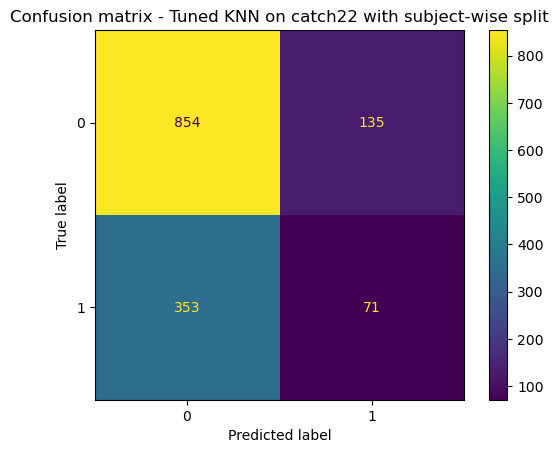

In [31]:
best_knn = grid_search.best_estimator_

best_knn_results = evaluate_classifier(
    best_knn,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Tuned KNN on catch22 with subject-wise split"
)

In [32]:
results_df = pd.DataFrame([
    baseline_results,
    best_knn_results
])

display(results_df.sort_values("test_balanced_accuracy", ascending=False))

NameError: name 'baseline_results' is not defined

Exception ignored in: <function ResourceTracker.__del__ at 0x105939bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1024f1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102a11bc0>
Traceback (most recent call last